### Tasks:
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
5.Apply Lasso and Ridge methods on the model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = pd.read_csv("ToyotaCorolla - MLR.csv")
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### Exploratory Data Analysis(EDA)

In [4]:
data.shape

(1436, 11)

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


#### Observation

The dataset contains both numerical and categorical variables. No missing values were found. The summary statistics indicate variation in Price, Age, KM, HP, and Weight, making them useful for regression analysis.

### Missing Values

In [7]:
data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

### Duplicate Values

In [8]:
data.duplicated().sum()

1

### Histograms

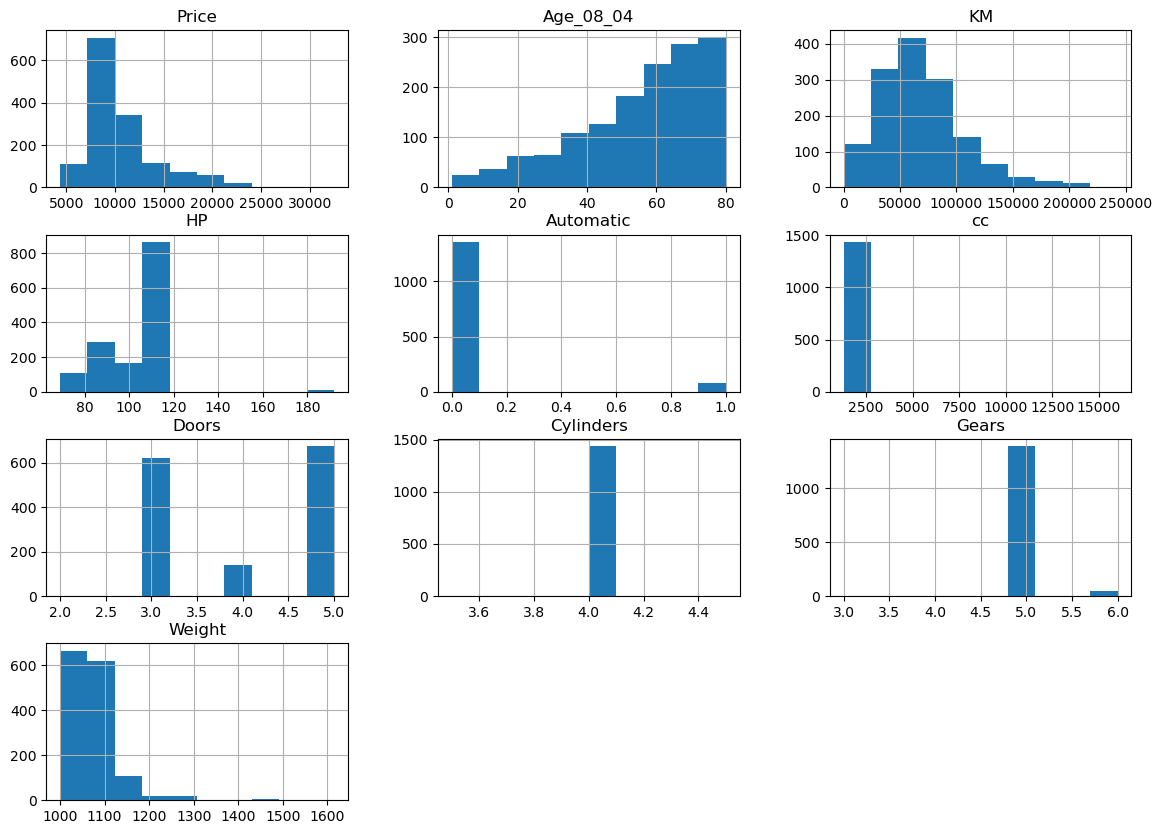

In [9]:
data.hist(figsize=(14, 10))
plt.show()

### Boxplots

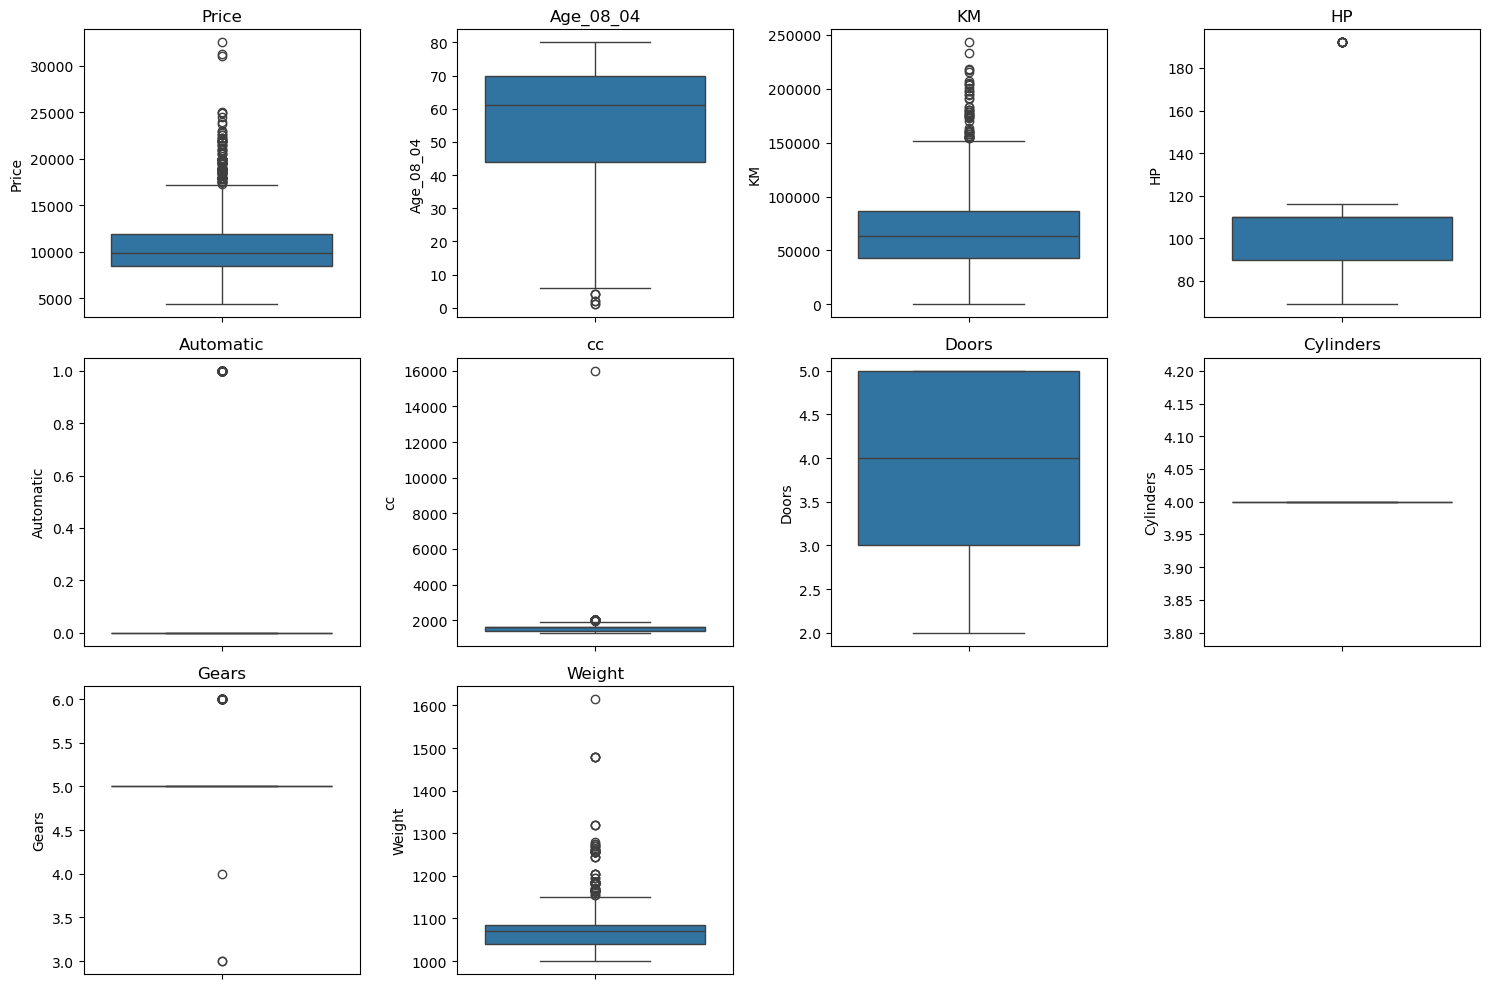

In [10]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(data.select_dtypes(include=np.number).columns):
    plt.subplot(3,4, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Observation
The boxplots indicate the presence of outliers in variables such as KM, HP, and Quarterly Tax. These outliers may influence the regression model and should be considered during preprocessing.

### Scatterplots

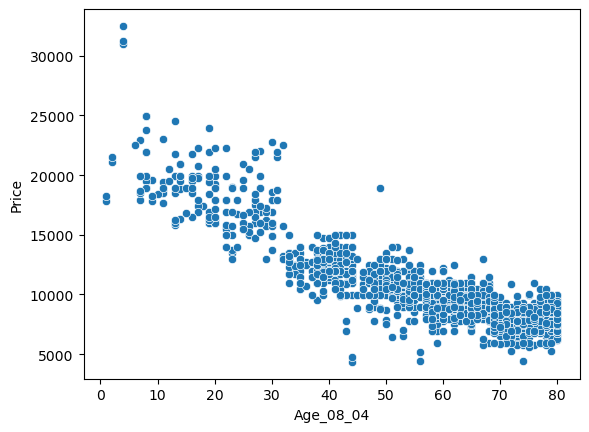

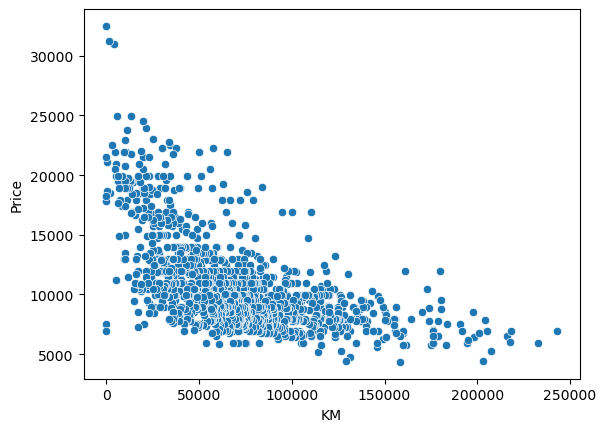

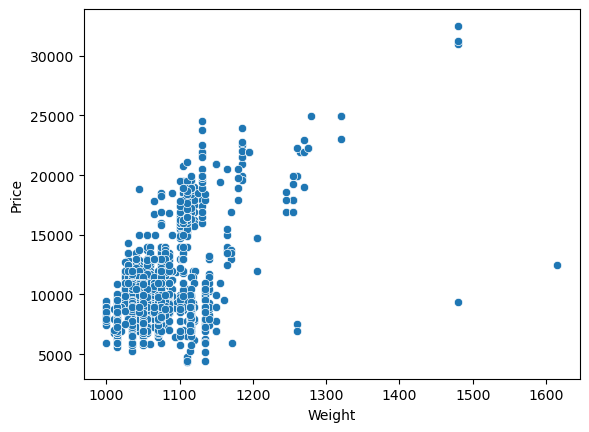

In [11]:
sns.scatterplot(x="Age_08_04", y="Price", data=data)
plt.show()

sns.scatterplot(x="KM", y="Price", data=data)
plt.show()

sns.scatterplot(x="Weight", y="Price", data=data)
plt.show()

### Correlation Heatmap

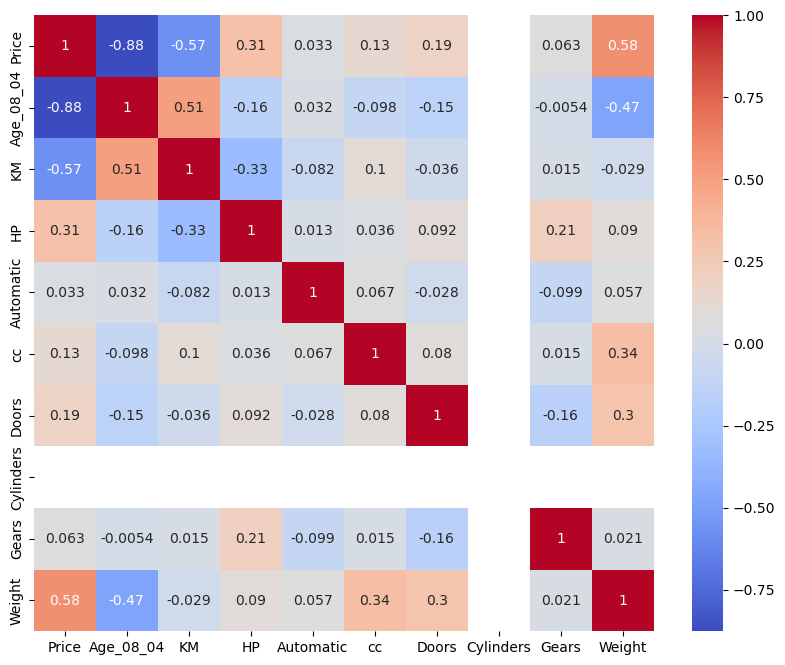

In [12]:
plt.figure(figsize=(10, 8))

sns.heatmap(data.corr(numeric_only=True),
           annot=True,
           cmap="coolwarm")
plt.show()

#### Observation:

Price has a strong negative relationship with Age and KM, indicating that older cars and cars with higher mileage generally have lower prices. Weight and HP show a positive relationship with Price.

### Pairplot

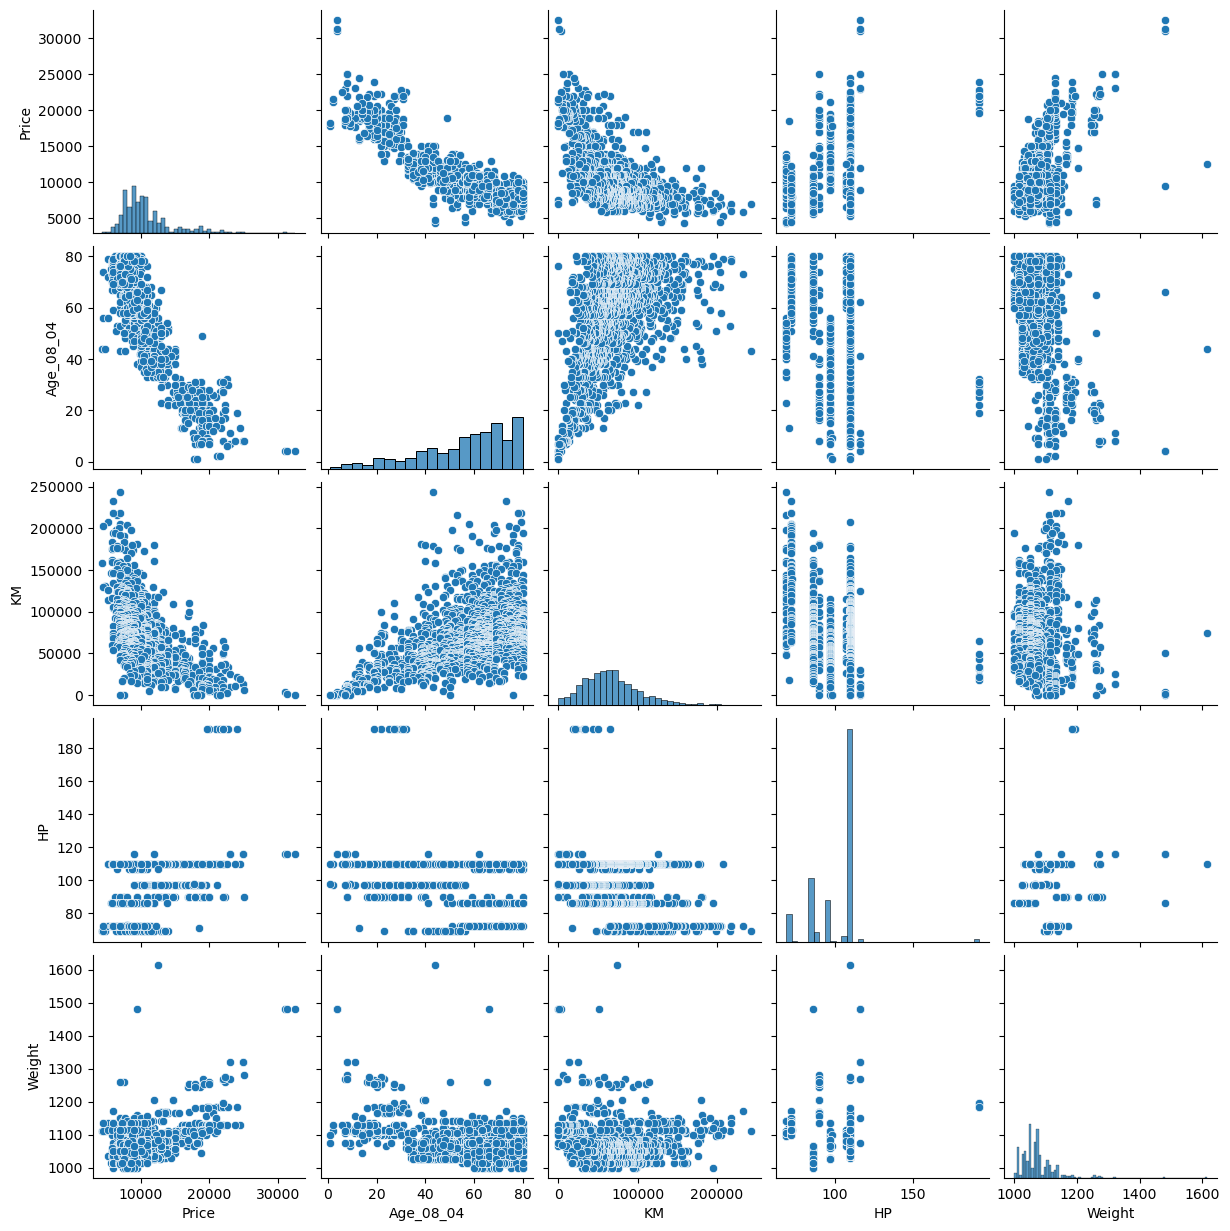

In [13]:
sns.pairplot(
    data[["Price", "Age_08_04", "KM","HP","Weight"]]
)
plt.show()

### Data Preprocessing

#### Encode Fuel Type

In [14]:
data = pd.get_dummies(
    data, 
    columns=["Fuel_Type"],
    drop_first=True
)
data.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


#### Define X and Y

In [15]:
X = data.drop("Price", axis=1)
y = data["Price"]

### Train - Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model 1 

In [17]:
model1 = LinearRegression()
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

print("R2 Score :", r2_score(y_test, pred1))
print("MAE :", mean_absolute_error(y_test, pred1))
print("MSE :", mean_absolute_error(y_test, pred1))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred1)))

R2 Score : 0.8348888040611082
MAE : 990.8872739193923
MSE : 990.8872739193923
RMSE : 1484.2654153296514


#### Observation:
The Multiple Linear Regression model was evaluated using R² Score, MAE, MSE, and RMSE. These metrics indicate the predictive performance of the model. A higher R² score and lower error values generally represent better model performance. These evaluation metrics can also be used to compare this model with the other regression models.

In [18]:
coef1 = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : model1.coef_
})
coef1

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.108447e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


### Model2

In [19]:
X2 = data[[
    "Age_08_04",
    "KM",
    "HP",
    "Weight"
]]

X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)
pred2=model2.predict(X_test)

#### Observation

Model 2 was evaluated using the same metrics. Comparing its R² score and error values with Model 1 helps determine whether using a smaller set of features improves or reduces prediction performance.

In [20]:
print("R2:", r2_score(y_test, pred2))
print("MAE :", mean_absolute_error(y_test, pred2))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred2)))

R2: 0.8506068681500583
MAE : 1001.2017466053624
RMSE : 1411.8502091132295


### Model3

In [21]:
X3 = data[[
    "Age_08_04",
    "HP",
    "Weight"
]]

X_train, X_test, y_train, y_test = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42
)

model3 = LinearRegression()
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)

In [22]:
print("R2:", r2_score(y_test, pred3))
print("MAE :", mean_absolute_error(y_test, pred3))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred3)))

R2: 0.8315557548230362
MAE : 1093.2552092820197
RMSE : 1499.1717697892254


#### Observation
Model 3 was evaluated and compared with the previous models. The model with the highest R squared score and the lowest MAE and RMSE is considered the best-performing model.

### Compare the Three Models

In [23]:
comparison = pd.DataFrame({
    "Model1":[
        "Model 1",
        "Model 2",
        "Model 3"
    ],

    "R2" : [
        r2_score(y_test, pred1),
        r2_score(y_test, pred2),
        r2_score(y_test, pred3)
    ]
})
comparison

,Model1,R2
0,Model 1,0.834889
1,Model 2,0.850607
2,Model 3,0.831556


### Lasso Regression

In [24]:
Lasso = Lasso(alpha=0.1)
Lasso.fit(X_train, y_train)

Lasso_pred = Lasso.predict(X_test)

print("R2:", r2_score(y_test, Lasso_pred))
print("MAE :", mean_absolute_error(y_test, Lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, Lasso_pred)))


R2: 0.8315558960588756
MAE : 1093.2544227242017
RMSE : 1499.171141282067


#### Observation:
Lasso Regression applies L1 regularization, which can reduce the impact of less important features by shrinking some coefficients toward zero. This helps reduce overfitting and performs feature selection.

In [25]:
Lasso_coef = pd.DataFrame({
    "Feature":X3.columns,
    "Coefficient":Lasso.coef_
})
Lasso_coef

,Feature,Coefficient
0,Age_08_04,-144.454051
1,HP,42.732254
2,Weight,15.417987


### Ridge Regression

In [26]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
print("R2:", r2_score(y_test, ridge_pred))
print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_pred)))


R2: 0.8315556099140967
MAE : 1093.2556076110025
RMSE : 1499.172414641605


#### Observation:
Ridge Regression applies L2 regularization, which reduces the magnitude of coefficients while keeping all features in the model. It is useful when predictor variables are highly correlated.

### Ridge Coefficients

In [27]:
ridge_coef = pd.DataFrame({
    "Feature" : X3.columns,
    "Coefficient" : ridge.coef_
})
ridge_coef

,Feature,Coefficient
0,Age_08_04,-144.453129
1,HP,42.732576
2,Weight,15.418175


#### Conclusion
Three Multiple Linear Regression models were developed to predict Toyota Corolla prices using different features. Their performances were evaluated using R² Score, MAE, MSE, and RMSE. Lasso and Ridge Regression were applied to reduce overfitting and improve model stability. Overall, variables such as Age, KM, HP, and Weight were found to be significant predictors of vehicle price.

In [28]:
results = pd.DataFrame({
    "Model" :[
        "Linear Regression",
        "Lasso",
        "Ridge"
    ],

    "R2 Score":[
        r2_score(y_test, pred3),
        r2_score(y_test, Lasso_pred),
        r2_score(y_test, ridge_pred)
    ],

    "MAE":[
        mean_absolute_error(y_test, pred3),
        mean_absolute_error(y_test, Lasso_pred),
        mean_absolute_error(y_test, ridge_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, pred3)),
        np.sqrt(mean_squared_error(y_test, Lasso_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.831556,1093.255209,1499.171770
1,Lasso,0.831556,1093.254423,1499.171141
2,Ridge,0.831556,1093.255608,1499.172415


### Assumptions:
1. The relationship between the predictor variables and Price is linear.
2. The observations are independent of each other.
3. The residual errors are normally distributed.
4. The variance of the residuals is constant.
5. There is little or no multicollinearity among the predictor variables.

### Implications

If these assumptions are violated, the model's predictions and coefficient estimates may become less reliable. Therefore, checking these assumptions helps ensure the regression model is accurate and suitable for prediction.

### INTERVIEW QUESTIONS

### 1.What is Normalization & Standardization and how is it helpful?
Normalization is a data preprocessing technique that scales feature values to a fixed range, usually 0 to 1, using Min-Max Scaling.

Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1 using Z-score scaling.

----> How are they helpful?

1. Bring features to a similar scale.
2. Improve the performance of machine learning algorithms.
3. Prevent features with larger values from dominating the model.
4. Help optimization algorithms converge faster.
5. Particularly useful for algorithms such as Linear Regression, Logistic Regression, KNN, SVM, and Neural Networks.


### 2.What techniques can be used to address multicollinearity in multiple linear regression?
Multicollinearity occurs when two or more independent variables are highly correlated, making it difficult to estimate the effect of each predictor accurately.

----> Techniques to address multicollinearity include:

1. Remove highly correlated features based on the correlation matrix.Remove highly correlated features based on the correlation matrix.
2. Apply Ridge Regression (L2 Regularization), which reduces coefficient variance caused by multicollinearity.
3. Apply LASSO Regression (L1 Regularization), which can shrink some coefficients to zero and perform feature selection.
4. Increase the dataset size, if possible, to improve model stability.
These techniques improve the reliability, interpretability, and predictive performance of the Multiple Linear Regression model.

